In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv('Pharma_Industry.csv')
df.shape

(500, 6)

In [3]:
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [4]:
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [6]:
df.isna().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

- there are no null values
- data types of all the column are correct
- i think the data is alredy scaled

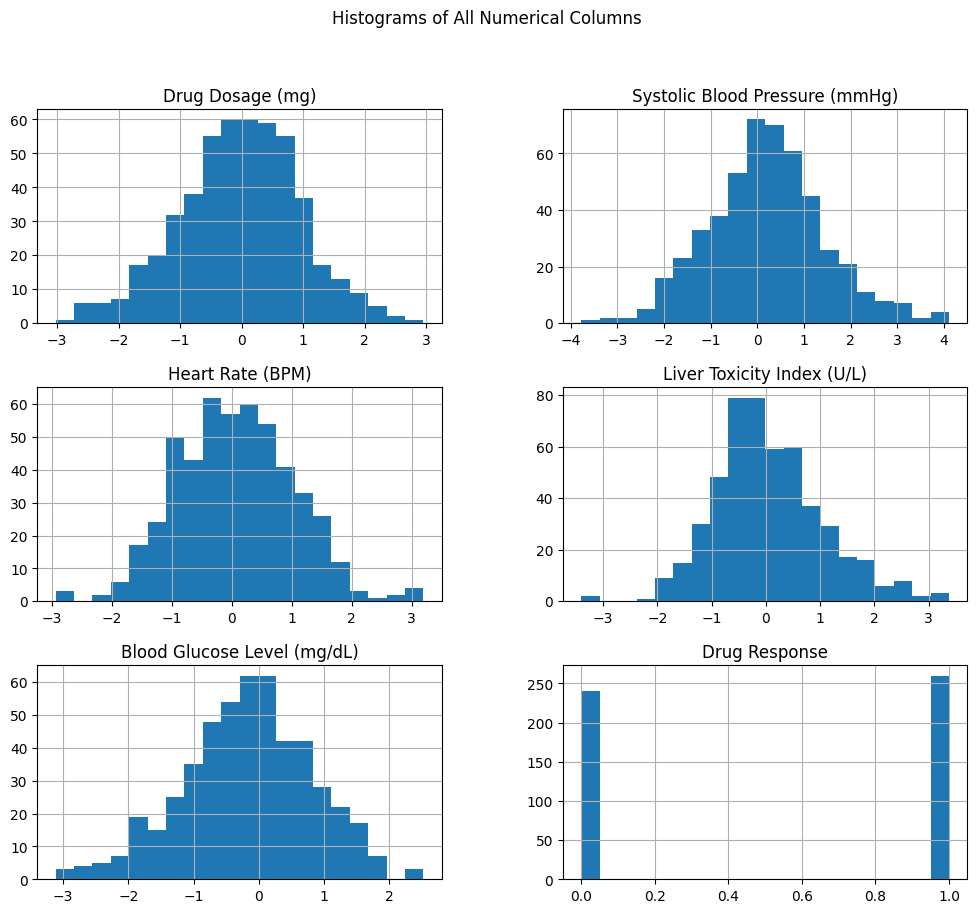

In [7]:
df.hist(figsize=(12, 10), bins=20, grid=True)
plt.suptitle("Histograms of All Numerical Columns")
plt.show()

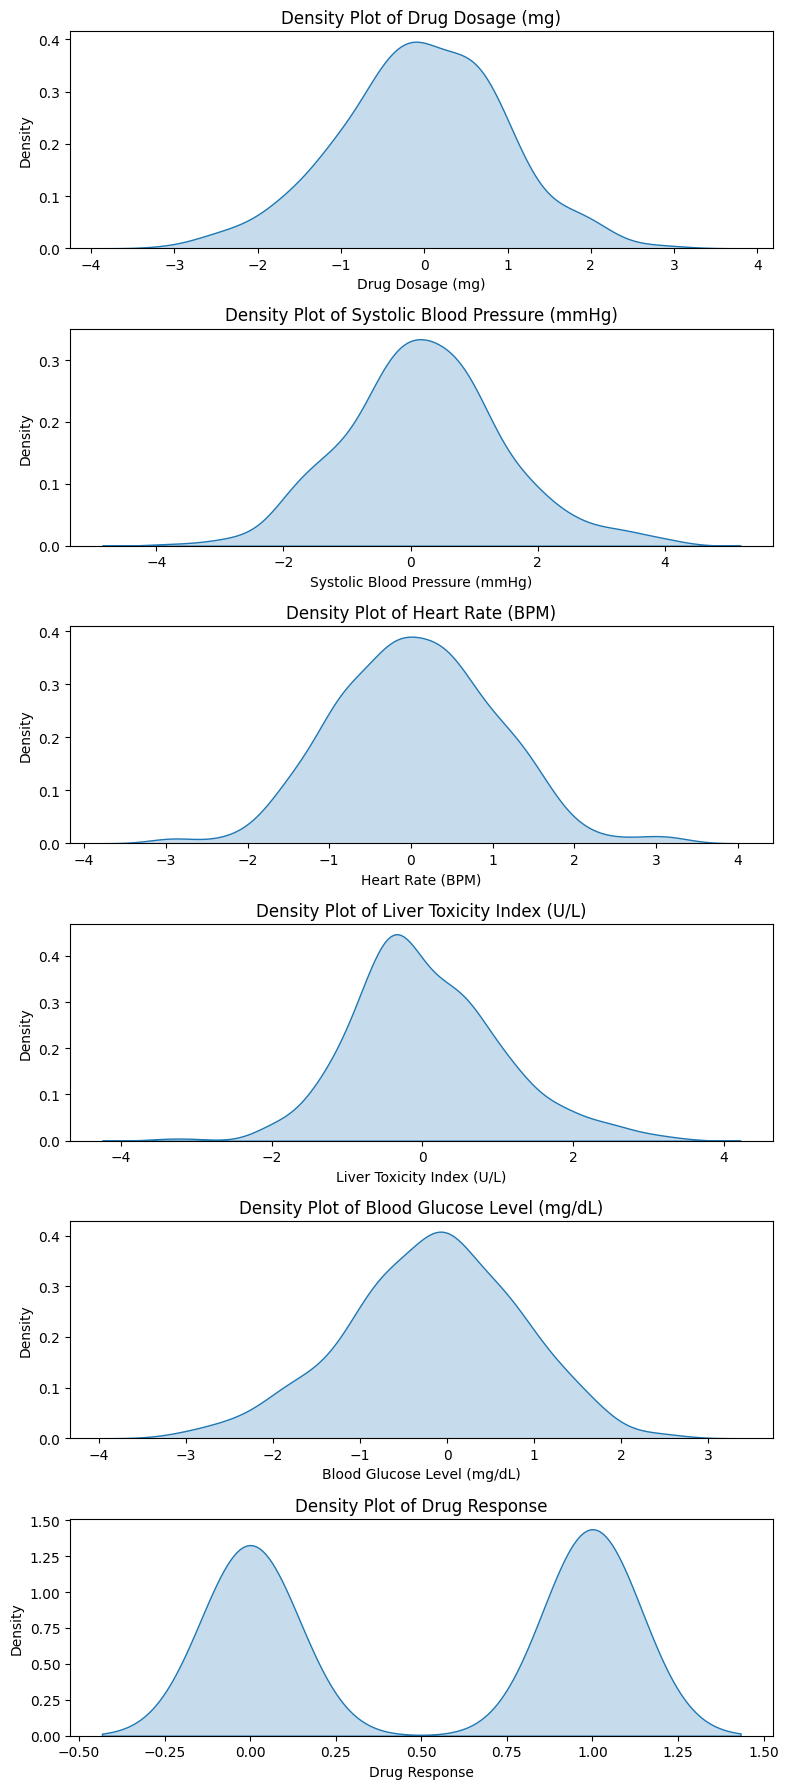

In [11]:
cols = df.columns
fig, axes = plt.subplots(nrows=len(cols), ncols=1, figsize=(8, 3 * len(cols)))

for i, col in enumerate(cols):
    sns.kdeplot(data=df, x=col, fill=True, ax=axes[i])
    axes[i].set_title(f'Density Plot of {col}')

plt.tight_layout()
plt.show()

- all the columns are almost symetrically distributed by the obsurvations from the histogram and Density Plots (KDE)

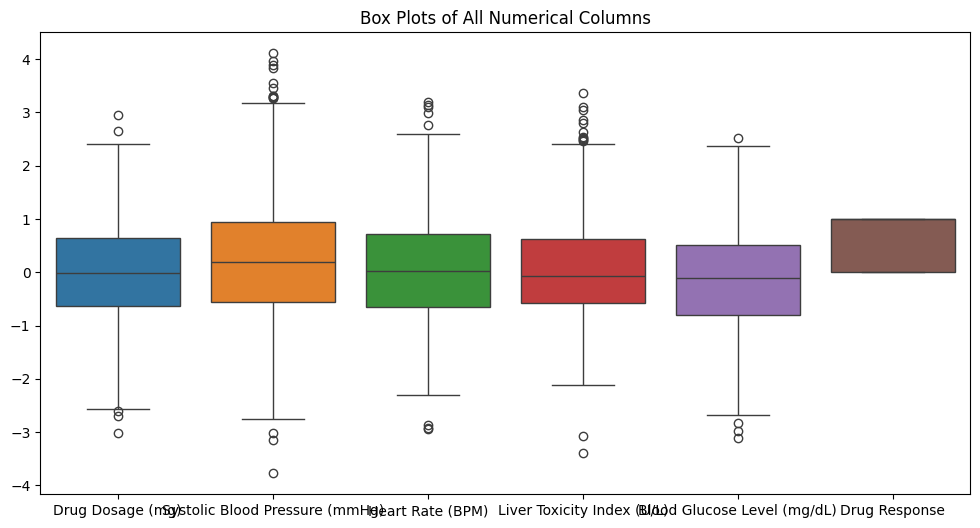

In [9]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.title("Box Plots of All Numerical Columns")
plt.show()

Box plots indicate the presence of a small number of potential outliers across several numerical features. Since the dataset appears to be standardized and the distributions are approximately symmetric, the outliers were investigated rather than immediately removed. These observations may represent legitimate variability within the data and could contain valuable information for classification. Their impact on the SVM model can be further assessed through model evaluation and hyperparameter tuning.

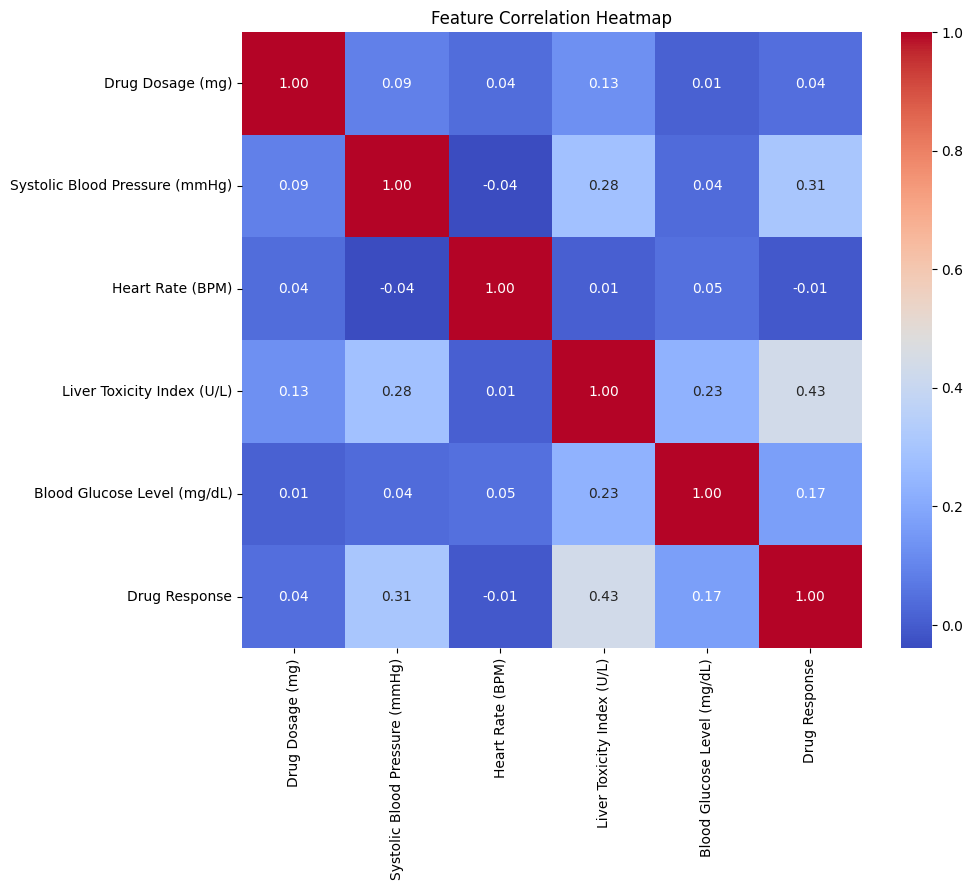

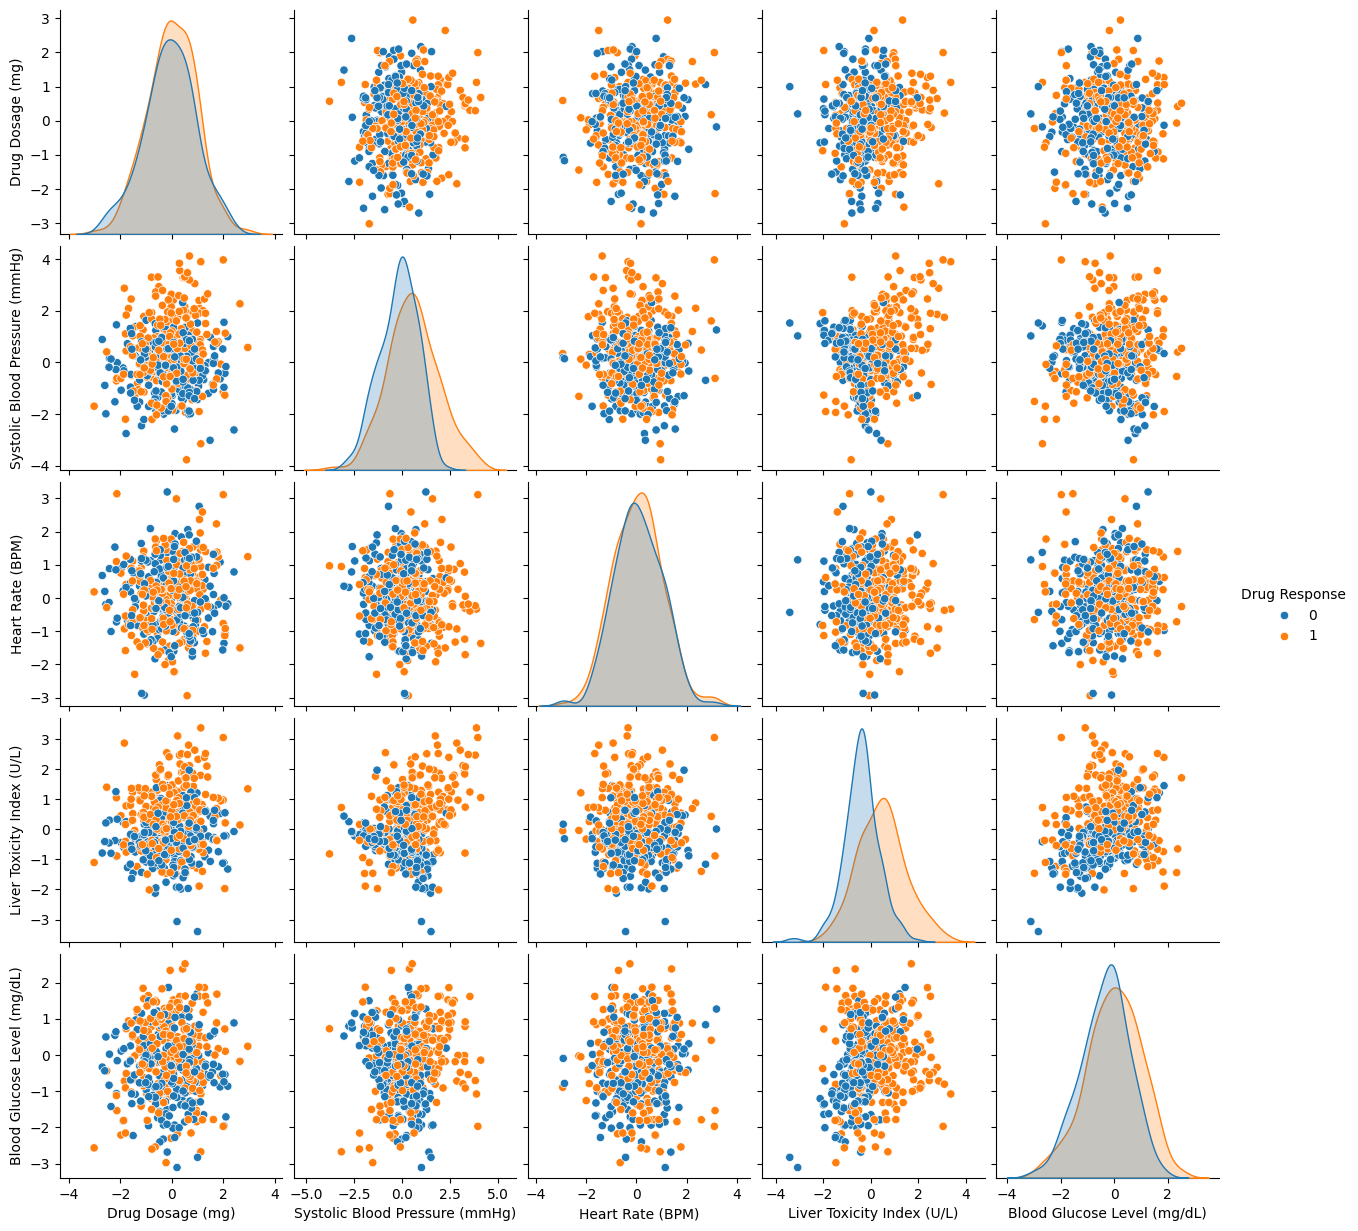

In [13]:
# 1. Visualize Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# 2. Visualize Pairwise Relationships
sns.pairplot(df, hue='Drug Response') # Replace with your target column name
plt.show()

- Since the features have very low correlation with each other, they are likely providing "independent" information to your model. You don't have to worry about redundant features causing issues.
- Target Drivers: Look at the bottom row of heatmap (or last column) which shows the correlation with Drug Response:
  - Liver Toxicity Index (0.43) has the strongest positive correlation with the drug response.
  - Systolic Blood Pressure (0.31) has a moderate positive correlation.
  - Heart Rate (-0.01) and Drug Dosage (0.04) show almost zero linear relationship with the outcome. This suggests that these two features may not be linearly predictive of the response, or their influence is highly non-linear (which is where SVMs with non-linear kernels are helpful).

#### Data Preprocessing

In [14]:
# Split the dataset into training and testing sets.
from sklearn.model_selection import train_test_split

In [17]:
x = df[["Drug Dosage (mg)", "Systolic Blood Pressure (mmHg)", "Heart Rate (BPM)", "Liver Toxicity Index (U/L)", "Blood Glucose Level (mg/dL)"]]
y = df["Drug Response"]

In [18]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [19]:
print(x_train.shape) 
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(350, 5)
(150, 5)
(350,)
(150,)


#### SVM Implementation

In [34]:
# # define svm model with different kernals
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [21]:
svm_linear = SVC(kernel="linear")
svm_poly = SVC(kernel="poly", degree=3)
svm_rbf = SVC(kernel="rbf", gamma =0.5)

In [27]:
# train svm moedl
svm_linear.fit(x_train, y_train)
y_pred_liner = svm_linear.predict(x_test)
accuricy_linear = accuracy_score(y_test, y_pred_liner)
classification_linear = classification_report(y_test, y_pred_liner)

In [28]:
# train svm with polynomial
svm_poly.fit(x_train, y_train)
y_pred_poly = svm_poly.predict(x_test)
accuracy_poly = accuracy_score(y_test, y_pred_poly)
classification_poly = classification_report(y_test, y_pred_poly)

In [29]:
# train svm with rbf kernal
svm_rbf.fit(x_train, y_train)
y_pred_rbf = svm_rbf.predict(x_test)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
classification_rbf = classification_report(y_test, y_pred_rbf)

In [30]:
print("Accuricy with linear kernal", accuricy_linear)
print("Accuricy with poly", accuracy_poly)
print("Accuricy with rbf", accuracy_rbf)

Accuricy with linear kernal 0.7066666666666667
Accuricy with poly 0.72
Accuricy with rbf 0.82


In [31]:
print("classification with linear kernal", classification_linear)
print("classification with poly kernal", classification_poly)
print("classification with rbf kernal", classification_rbf)


classification with linear kernal               precision    recall  f1-score   support

           0       0.65      0.80      0.71        69
           1       0.78      0.63      0.70        81

    accuracy                           0.71       150
   macro avg       0.72      0.71      0.71       150
weighted avg       0.72      0.71      0.71       150

classification with poly kernal               precision    recall  f1-score   support

           0       0.65      0.86      0.74        69
           1       0.83      0.60      0.70        81

    accuracy                           0.72       150
   macro avg       0.74      0.73      0.72       150
weighted avg       0.75      0.72      0.72       150

classification with rbf kernal               precision    recall  f1-score   support

           0       0.78      0.86      0.81        69
           1       0.86      0.79      0.83        81

    accuracy                           0.82       150
   macro avg       0.82      0.

#### Visualization of SVM Results

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

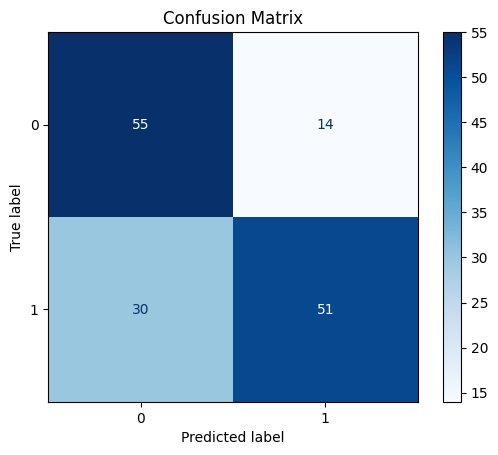

In [35]:
cm = confusion_matrix(y_test, y_pred_liner)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [37]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_rbf
})

print(results.head(20))

     Actual  Predicted
361       0          0
73        0          0
374       1          0
155       1          1
104       0          0
394       0          0
377       1          1
124       1          0
68        0          0
450       1          0
9         0          0
194       1          1
406       0          0
84        0          0
371       0          0
388       0          0
495       0          0
30        0          0
316       0          0
408       1          1


#### Parameter Tuning and Optimization

In [41]:
kernels = ['linear', 'rbf', 'poly', 'sigmoid']

for kernel in kernels:
    model = SVC(kernel=kernel)
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)

    print(f"Kernel: {kernel}")
    print(f"Accuracy: {accuracy:.4f}")
    print("-"*30)

Kernel: linear
Accuracy: 0.7067
------------------------------
Kernel: rbf
Accuracy: 0.7933
------------------------------
Kernel: poly
Accuracy: 0.7200
------------------------------
Kernel: sigmoid
Accuracy: 0.6800
------------------------------


The RBF kernel produced the highest classification accuracy and was selected for further optimization.

In [42]:
C_values = [0.1, 1, 10, 100]

for c in C_values:

    model = SVC(
        kernel='rbf',
        C=c
    )

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)

    print(f"C = {c}, Accuracy = {accuracy:.4f}")

C = 0.1, Accuracy = 0.7400
C = 1, Accuracy = 0.7933
C = 10, Accuracy = 0.7867
C = 100, Accuracy = 0.7733


c = 1 best

In [43]:
gamma_values = [1, 0.1, 0.01, 0.001]

for gamma in gamma_values:

    model = SVC(
        kernel='rbf',
        C=1,
        gamma=gamma
    )

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)

    print(f"Gamma = {gamma}, Accuracy = {accuracy:.4f}")

Gamma = 1, Accuracy = 0.7733
Gamma = 0.1, Accuracy = 0.7867
Gamma = 0.01, Accuracy = 0.7067
Gamma = 0.001, Accuracy = 0.6933


In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.1, 0.01, 0.001]
}

grid = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': ['scale', 0.1, 0.01, 0.001],
                         'kernel': ['linear', 'rbf', 'poly']},
             scoring='accuracy')

In [45]:
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV Score: 0.7457142857142858


Multiple SVM configurations were evaluated by varying kernel type, regularization parameter (C), and gamma. Hyperparameter optimization was performed using GridSearchCV with 5-fold cross-validation. The RBF kernel with C = 1 and gamma = 0.1 achieved the highest classification accuracy and was selected as the final model.

#### Conclusion

SVM is a reliable and widely used classification algorithm in domains such as healthcare, finance, cybersecurity, image processing, and text analytics. Its ability to achieve high accuracy and handle complex decision boundaries makes it valuable for many real-world classification tasks. However, careful hyperparameter tuning and computational considerations are necessary when applying SVM to large-scale datasets.